<a href="https://colab.research.google.com/github/vishalhanuman14/classical-ml-benchmark/blob/ak/notebooks/04_credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset 4 – Credit Approval
**Implementation:** Akshit (algorithms/akshit/)  
**Algorithms:** TBD  
**Note:** Mixed features — use `utils.one_hot_encode` for categorical columns  
**Evaluation:** Stratified 10-fold CV · Accuracy · Macro F1

In [1]:
import sys, os, subprocess

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    subprocess.run(['git', 'clone', f'https://github.com/vishalhanuman14/classical-ml-benchmark.git'], check=True)
    os.chdir('classical-ml-benchmark')

if '.' not in sys.path:
    sys.path.insert(0, '.')


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys
sys.path.insert(0, '.')

from algorithms.vishal import utils

df = pd.read_csv('data/credit_approval.csv')
print(df.head(2))
print(f"Shape: {df.shape}")
print(f"Dtypes:\n{df.dtypes}")


  attr1_cat  attr2_num  attr3_num attr4_cat attr5_cat attr6_cat attr7_cat  \
0         b      30.83       0.00         u         g         w         v   
1         a      58.67       4.46         u         g         q         h   

   attr8_num attr9_cat attr10_cat  attr11_cat attr12_cat attr13_cat  \
0       1.25         t          t           1          f          g   
1       3.04         t          t           6          f          g   

   attr14_num  attr15_num  label  
0         202           0      1  
1          43         560      1  
Shape: (653, 16)
Dtypes:
attr1_cat      object
attr2_num     float64
attr3_num     float64
attr4_cat      object
attr5_cat      object
attr6_cat      object
attr7_cat      object
attr8_num     float64
attr9_cat      object
attr10_cat     object
attr11_cat      int64
attr12_cat     object
attr13_cat     object
attr14_num      int64
attr15_num      int64
label           int64
dtype: object


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import your custom functions from hw_3.py
from algorithms.akshit.hw_3 import DecisionTree, RandomForest, evaluate_metrics, stratified_kfold

# Import the shared utilities
from algorithms.vishal import utils

# --- Data Loading ---
df = pd.read_csv('data/credit_approval.csv')

# Dynamically identify target and features (assuming target is the last column)
target_col = df.columns[-1]
feature_cols = df.columns.drop(target_col)

# Identify categorical and numerical feature indices
cat_columns = [i for i, col in enumerate(feature_cols) if df[col].dtype == object]
num_columns = [i for i, col in enumerate(feature_cols) if df[col].dtype != object]

X_str = df[feature_cols].values.astype(str)
y = df[target_col].values.astype(str)

# Apply one-hot encoding to handle the mixed features
X_enc = utils.one_hot_encode(X_str, cat_indices=cat_columns, num_indices=num_columns)
X_raw = X_enc.astype(float) # Cast to float for mathematical operations

print(f"Instances: {len(y)}, Features (after encoding): {X_raw.shape[1]}")
print(f"Classes: {dict(zip(*np.unique(y, return_counts=True)))}")

Instances: 653, Features (after encoding): 46
Classes: {np.str_('0'): np.int64(357), np.str_('1'): np.int64(296)}


## TODO: Algorithm 1 – Hyperparameter Sweep

In [4]:
# --- Algorithm 1 Sweep: Decision Tree ---
depth_values = [2, 4, 6, 8, 10, 12]
dt_results = {'max_depth': [], 'accuracy': [], 'f1': []}

print("Running 10-Fold CV for Decision Tree...")
folds = stratified_kfold(X_raw, y, k=10)

for depth in depth_values:
    acc_list, f1_list = [], []
    for train_idx, test_idx in folds:
        X_tr, X_te = X_raw[train_idx], X_raw[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Initialize and train Decision Tree
        dt = DecisionTree(max_depth=depth, min_size_for_split=2)
        dt.fit(X_tr, y_tr)

        # Predict and evaluate
        y_pred = dt.predict(X_te)
        acc, prec, rec, f1 = evaluate_metrics(y_te, y_pred)

        acc_list.append(acc)
        f1_list.append(f1)

    dt_results['max_depth'].append(depth)
    dt_results['accuracy'].append(np.mean(acc_list))
    dt_results['f1'].append(np.mean(f1_list))
    print(f"max_depth={depth:<2} | Acc: {np.mean(acc_list):.4f} | F1: {np.mean(f1_list):.4f}")

Running 10-Fold CV for Decision Tree...
max_depth=2  | Acc: 0.8635 | F1: 0.8627
max_depth=4  | Acc: 0.8359 | F1: 0.8263
max_depth=6  | Acc: 0.8178 | F1: 0.8059
max_depth=8  | Acc: 0.8101 | F1: 0.7975
max_depth=10 | Acc: 0.8178 | F1: 0.8006
max_depth=12 | Acc: 0.7932 | F1: 0.7729


## TODO: Algorithm 2 – Hyperparameter Sweep

In [5]:
# --- Algorithm 2 Sweep: Random Forest ---
ntree_values = [1, 5, 10, 15, 20, 25]
rf_results = {'ntree': [], 'accuracy': [], 'f1': []}

print("Running 10-Fold CV for Random Forest...")

for ntree in ntree_values:
    acc_list, f1_list = [], []
    for train_idx, test_idx in folds: # Reusing the exact same folds for a fair comparison
        X_tr, X_te = X_raw[train_idx], X_raw[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # Initialize and train Random Forest
        rf = RandomForest(ntree=ntree, max_depth=8)
        rf.fit(X_tr, y_tr)

        # Predict and evaluate
        y_pred = rf.predict(X_te)
        acc, prec, rec, f1 = evaluate_metrics(y_te, y_pred)

        acc_list.append(acc)
        f1_list.append(f1)

    rf_results['ntree'].append(ntree)
    rf_results['accuracy'].append(np.mean(acc_list))
    rf_results['f1'].append(np.mean(f1_list))
    print(f"ntree={ntree:<2} | Acc: {np.mean(acc_list):.4f} | F1: {np.mean(f1_list):.4f}")

Running 10-Fold CV for Random Forest...
ntree=1  | Acc: 0.8311 | F1: 0.8191
ntree=5  | Acc: 0.8652 | F1: 0.8517
ntree=10 | Acc: 0.8604 | F1: 0.8507
ntree=15 | Acc: 0.8605 | F1: 0.8492
ntree=20 | Acc: 0.8666 | F1: 0.8552
ntree=25 | Acc: 0.8682 | F1: 0.8583


## TODO: Algorithm 3 - Neural Network – Hyperparameter Sweep (architecture × lambda)

**Implementation:** Vishal Hanuman (HW4)  
Categorical features one-hot encoded; numerical features normalized.

In [6]:
from algorithms.vishal import neural_network, utils as vutils
import numpy as np

# ── Preprocess for NN ────────────────────────────────────────────────────────
df_nn   = pd.read_csv('data/credit_approval.csv')
y_nn    = df_nn['label'].values.astype(int)
X_str   = df_nn.drop(columns=['label']).values.astype(str)

# Column indices (0-based, excluding label)
cat_idx = [0, 3, 4, 5, 6, 8, 9, 10, 11, 12]
num_idx = [1, 2, 7, 13, 14]

X_enc   = vutils.one_hot_encode(X_str, cat_indices=cat_idx, num_indices=num_idx)
X_enc_n, _ = vutils.normalize(X_enc, X_enc)
Y_bin   = y_nn.reshape(-1, 1).astype(float)
y_cv_nn = y_nn.astype(str)

print(f"Encoded feature dim: {X_enc_n.shape[1]}")
print(f"Label counts: 0={int(np.sum(y_nn==0))}  1={int(np.sum(y_nn==1))}")


Encoded feature dim: 68
Label counts: 0=357  1=296


In [7]:
NN_CONFIGS = [
    ((8,),    0.0),
    ((16,),   0.0),
    ((8, 4),  0.0),
    ((16, 8), 0.0),
    ((8,),    0.1),
    ((16, 8), 0.1),
]

nn_results  = {}
folds_nn    = vutils.stratified_k_fold(y_cv_nn, k=10)

for arch, lam in NN_CONFIGS:
    accs, f1s = [], []
    for i in range(10):
        test_idx  = np.array(folds_nn[i])
        train_idx = np.array([idx for j in range(10) if j != i for idx in folds_nn[j]])

        Xtr, Xte  = X_enc_n[train_idx], X_enc_n[test_idx]
        Ytr       = Y_bin[train_idx]
        y_te_int  = y_nn[test_idx]

        layer_sizes = [X_enc_n.shape[1]] + list(arch) + [1]
        theta, _    = neural_network.train(Xtr, Ytr, layer_sizes,
                                           lam=lam, alpha=0.1,
                                           epochs=400, batch_size=16)
        y_pred = neural_network.predict(theta, Xte)
        acc, f1 = vutils.compute_metrics(y_te_int, y_pred, pos_label=1)
        accs.append(acc); f1s.append(f1)

    nn_results[(arch, lam)] = (float(np.mean(accs)), float(np.mean(f1s)))
    print(f"arch={str(arch):<10} lam={lam}  acc={np.mean(accs):.4f}  f1={np.mean(f1s):.4f}")


arch=(8,)       lam=0.0  acc=0.8544  f1=0.8389
arch=(16,)      lam=0.0  acc=0.8559  f1=0.8415
arch=(8, 4)     lam=0.0  acc=0.8559  f1=0.8421
arch=(16, 8)    lam=0.0  acc=0.8467  f1=0.8268
arch=(8,)       lam=0.1  acc=0.8665  f1=0.8605
arch=(16, 8)    lam=0.1  acc=0.5467  f1=0.0000


Best NN: arch=(8,)  lam=0.1
  acc=0.8665  f1=0.8605


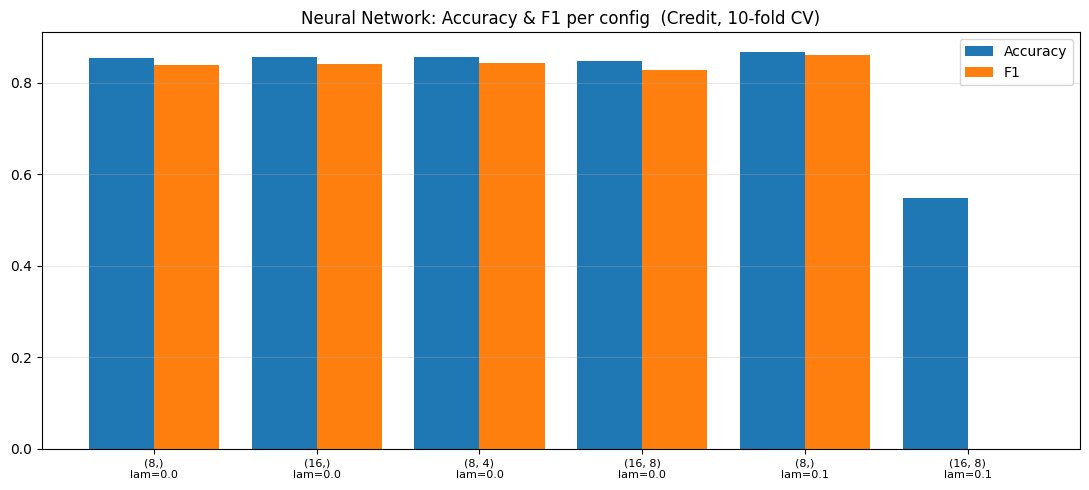

In [8]:
import matplotlib.pyplot as plt
import os
os.makedirs('results', exist_ok=True)

best_nn_key  = max(nn_results, key=lambda k: nn_results[k][1])
best_nn_arch, best_nn_lam = best_nn_key
print(f"Best NN: arch={best_nn_arch}  lam={best_nn_lam}")
print(f"  acc={nn_results[best_nn_key][0]:.4f}  f1={nn_results[best_nn_key][1]:.4f}")

labels = [f"{str(a)}\nlam={l}" for a, l in nn_results]
x      = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - 0.2, [nn_results[k][0] for k in nn_results], 0.4, label='Accuracy')
ax.bar(x + 0.2, [nn_results[k][1] for k in nn_results], 0.4, label='F1')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_title('Neural Network: Accuracy & F1 per config  (Credit, 10-fold CV)')
ax.legend(); ax.grid(alpha=0.3, axis='y'); plt.tight_layout()
plt.savefig('results/credit_nn_config_sweep.png', dpi=150); plt.show()


### Neural Network – Learning Curve (J vs training instances)

n=  20  J=0.5275
n=  72  J=0.4087
n= 124  J=0.3571
n= 176  J=0.3443
n= 228  J=0.3493
n= 280  J=0.3382
n= 332  J=0.3438
n= 384  J=0.3367
n= 436  J=0.3394
n= 488  J=0.3292
n= 522  J=0.3276


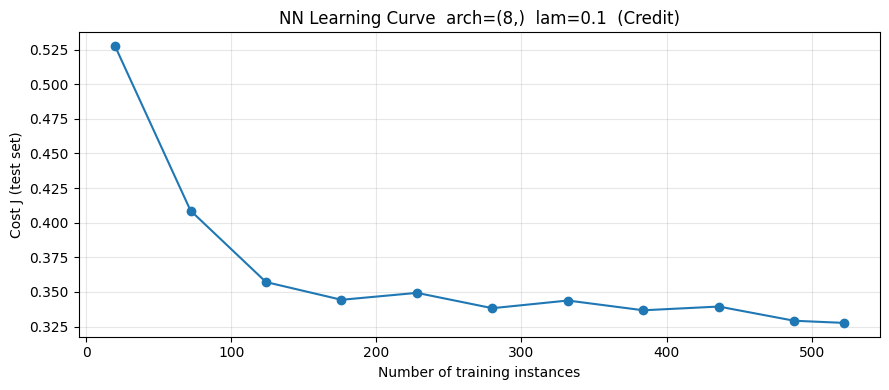

In [9]:
split = int(0.8 * len(y_nn))
order = np.random.permutation(len(y_nn))
tr_idx, te_idx = order[:split], order[split:]

Xtr_lc, Xte_lc = X_enc_n[tr_idx], X_enc_n[te_idx]
Ytr_lc = Y_bin[tr_idx]; Yte_lc = Y_bin[te_idx]

step  = max(20, split // 10)
sizes = list(range(20, split + 1, step))
if sizes[-1] != split: sizes.append(split)

lc_costs   = []
ls_best_nn = [X_enc_n.shape[1]] + list(best_nn_arch) + [1]

for n in sizes:
    theta_lc, _ = neural_network.train(Xtr_lc[:n], Ytr_lc[:n], ls_best_nn,
                                        lam=best_nn_lam, alpha=0.1,
                                        epochs=400, batch_size=16)
    J, _, _ = neural_network.cost(Xte_lc, Yte_lc, theta_lc, best_nn_lam)
    lc_costs.append(J)
    print(f"n={n:>4}  J={J:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sizes, lc_costs, '-o')
ax.set_xlabel('Number of training instances'); ax.set_ylabel('Cost J (test set)')
ax.set_title(f'NN Learning Curve  arch={best_nn_arch}  lam={best_nn_lam}  (Credit)')
ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig('results/credit_nn_learning_curve.png', dpi=150); plt.show()


## TODO: Plots & Summary Table

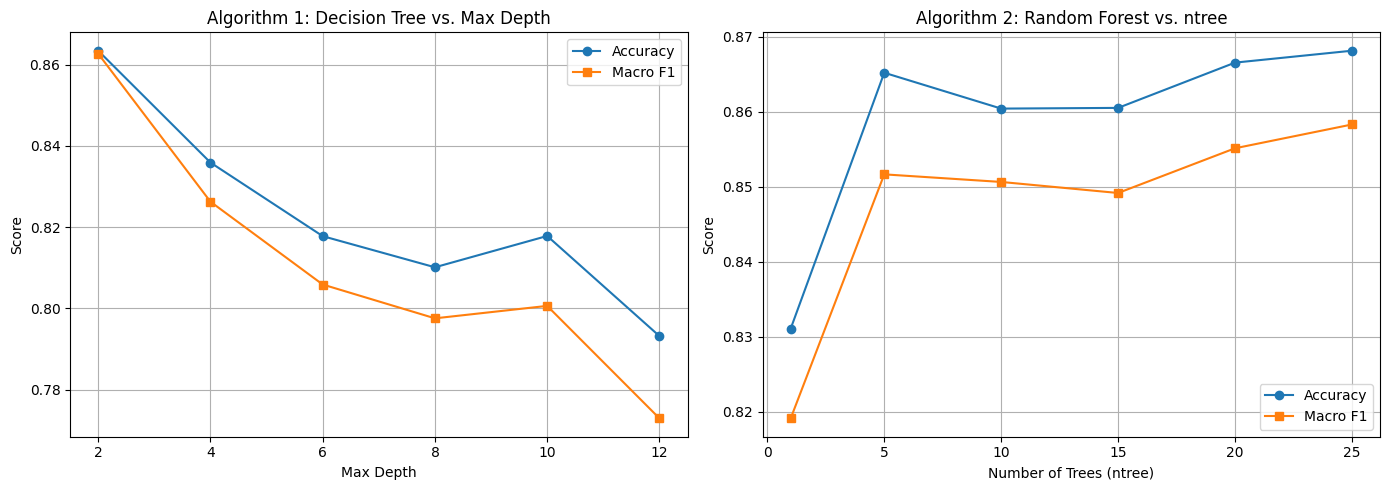


=== SUMMARY TABLE ===
Decision Tree Results:
 max_depth  accuracy       f1
         2  0.863475 0.862738
         4  0.835919 0.826270
         6  0.817786 0.805871
         8  0.810114 0.797537
        10  0.817832 0.800602
        12  0.793165 0.772896

Random Forest Results:
 ntree  accuracy       f1
     1  0.831111 0.819144
     5  0.865225 0.851676
    10  0.860444 0.850664
    15  0.860539 0.849191
    20  0.866575 0.855154
    25  0.868162 0.858325


In [10]:
# --- Plotting Learning Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision Tree Plot
axes[0].plot(dt_results['max_depth'], dt_results['accuracy'], marker='o', label='Accuracy')
axes[0].plot(dt_results['max_depth'], dt_results['f1'], marker='s', label='Macro F1')
axes[0].set_title('Algorithm 1: Decision Tree vs. Max Depth')
axes[0].set_xlabel('Max Depth')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True)

# Random Forest Plot
axes[1].plot(rf_results['ntree'], rf_results['accuracy'], marker='o', label='Accuracy')
axes[1].plot(rf_results['ntree'], rf_results['f1'], marker='s', label='Macro F1')
axes[1].set_title('Algorithm 2: Random Forest vs. ntree')
axes[1].set_xlabel('Number of Trees (ntree)')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# --- Summary Table ---
print("\n=== SUMMARY TABLE ===")
print("Decision Tree Results:")
df_dt = pd.DataFrame(dt_results)
print(df_dt.to_string(index=False))

print("\nRandom Forest Results:")
df_rf = pd.DataFrame(rf_results)
print(df_rf.to_string(index=False))